# Closing the loop — Build, Test and Learn

The other synbio tutorials all live in **Design**. They produce a pathway, an enzyme, a construct, a vector — knowledge. None of them produces anything a robot can execute, turns an instrument's output into a number, or decides what to do next. Design-build-test-learn was a claim about one letter out of four.

This notebook runs the other three, and then the arrow back to Design:

1. **Design** a combinatorial space and choose which corners of it to actually build.
2. **Build** — plate layout, equimolar assembly volumes, an Echo pick list, a runnable Opentrons protocol, a thermocycler program.
3. **Test** — fit a *real* 96-well plate-reader run, and set the measured growth rate beside what the metabolic model predicts.
4. **Learn** — main effects and curvature from the screening round, then a Gaussian process choosing the next batch.
5. **Tune** — the pieces that decide whether the design works *at the level you wanted*: tAI, a graded RBS library, integration sites, plasmid burden.

The growth data is measured, not simulated. A fitter shown only on curves produced by its own equations has not been shown to work on anything.


## 0 — Setup


In [1]:
import os

os.environ.setdefault('OMICOS_SYNBIO_GEM_DIR', os.path.expanduser('~/.omicverse/synbio_gems'))
import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


## 1 — Design: which corners of the space to build

Three factors — promoter strength, RBS strength, plasmid copy number — is already 256 experiments if you take eight levels of each, and a full factorial at two levels is 8. The interesting question is what to do with *eight* factors, where the full factorial is 256 runs and a round costs weeks.

`doe_design` offers the designs that answer that, and they trade different things away:


In [2]:
factors = {'promoter': (0.05, 1.0), 'rbs': (1.0, 1000.0), 'copies': (1.0, 20.0)}
for name in ('full_factorial', 'fractional_factorial', 'plackett_burman',
             'definitive_screening', 'central_composite', 'box_behnken'):
    print(f'  {name:22s} {ov.synbio.doe_design(factors, design=name).n_runs:3d} runs')


  full_factorial           8 runs
  fractional_factorial     8 runs
  plackett_burman          4 runs
  definitive_screening     7 runs
  central_composite       17 runs
  box_behnken             15 runs


With three factors the savings are modest. With eight they are the whole argument:


In [3]:
wide = {f'gene{i}': (0.0, 1.0) for i in range(8)}
frac = ov.synbio.doe_design(wide, design='fractional_factorial', resolution=4)
print(f'8 factors: {2 ** 8} runs full factorial, {frac.n_runs} at resolution IV')
print(frac.notes[0])


8 factors: 256 runs full factorial, 16 at resolution IV
resolution 4: 主效应与二因子交互不混淆


Resolution IV is the level that matters for a screening round: main effects stay unconfounded with two-factor interactions, so the ranking that comes out is interpretable. Plackett-Burman is cheaper still but confounds them completely, and a definitive screening design additionally makes curvature estimable — so a quadratic optimum shows up in round one instead of being discovered later.

For this run we take a central composite design, because we want the curvature.


In [4]:
design = ov.synbio.doe_design(factors, design='central_composite')
print(design)
print(design.to_frame().head(4).round(2).to_string())


Design(central_composite, 17 runs, 3 factors)
      promoter     rbs  copies
run1      0.05     1.0     1.0
run2      0.05     1.0    20.0
run3      0.05  1000.0     1.0
run4      0.05  1000.0    20.0


## 2 — Build: from a design matrix to something a robot runs

### 2.1 Where things go

Every downstream artefact consumes a plate, so the layout comes first. Controls are placed before the items, so they land somewhere predictable rather than wherever the items happen to run out.


In [5]:
constructs = [f'run{i + 1}' for i in range(design.n_runs)]
plate = ov.synbio.plate_layout(constructs, plate='96', controls=['blank', 'wt'],
                               name='assemblies')
print(plate)


Plate('assemblies', 96-well, 19/96 used)


(<Figure size 755.2x524.8 with 1 Axes>,
 <Axes: title={'center': 'assemblies (96-well, 19/96 filled)'}>)

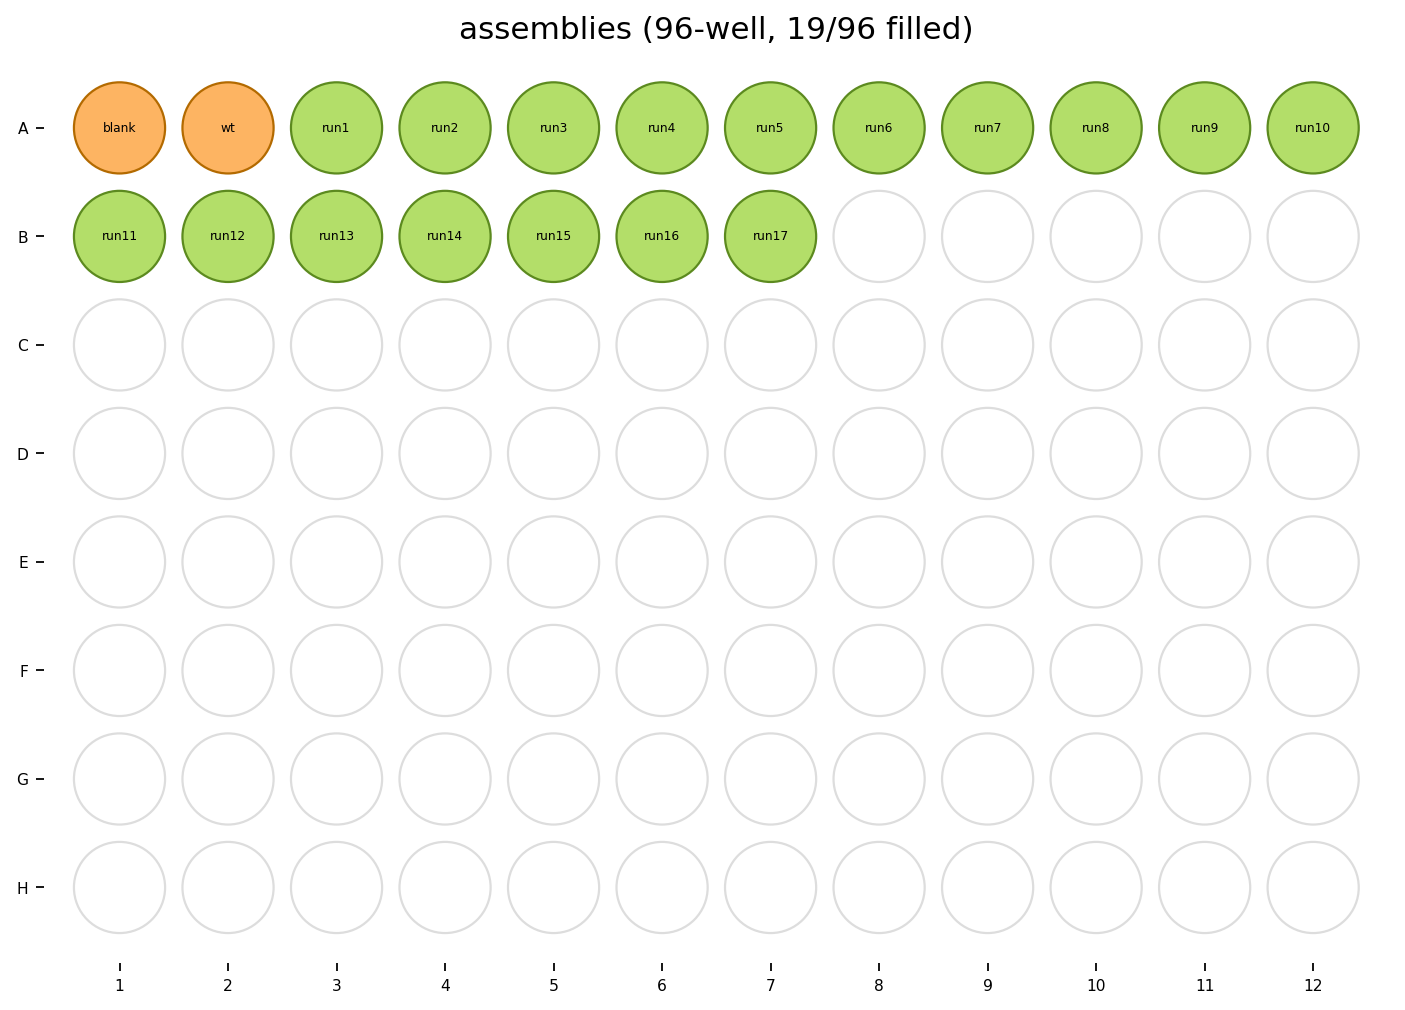

In [6]:
ov.synbio.plot_plate(plate, highlight=['blank', 'wt'])


### 2.2 How much of each fragment

This is the calculation done by hand before every assembly, and the one most often done wrong. Equal volumes of fragments at equal ng/µL are **not** equimolar as soon as the fragments differ in length — mass concentration has to be converted to molarity first.


In [7]:
fragments = {'backbone': (2686, 48.0), 'insertA': (912, 31.0), 'insertB': (604, 12.5)}
worklist = ov.synbio.assembly_worklist(fragments, method='golden_gate')
print(worklist)
print(worklist.to_frame().to_string(index=False))


Worklist(golden_gate, 5 transfers, 20.0 µL total)
                  item source_plate source_well dest_plate dest_well  volume_ul
              backbone    fragments              reactions        A1      0.727
               insertA    fragments              reactions        A1      0.765
               insertB    fragments              reactions        A1      1.256
golden_gate_master_mix     reagents              reactions        A1     10.000
                 water     reagents              reactions        A1      7.252


The backbone is 3x the length of insertB at 4x the concentration, and it still needs a comparable volume — that is the conversion doing its job. Anything the function cannot ask a pipette for is reported with the dilution that fixes it, rather than emitted as an unpipettable number:


In [8]:
for note in worklist.notes:
    print('-', note)


- golden_gate: master mix 50% of 20.0 µL
- backbone taken as 'backbone' (2686 bp) — the longest fragment; pass backbone= if that is wrong


### 2.3 An Echo pick list

The Echo Cherry Pick application reads specific column names, so they are produced exactly rather than approximated. Volumes come out in **nanolitres**, snapped to the instrument's 2.5 nL droplet — a volume the Echo cannot dispense is not a volume, and µL here would be a 1000-fold error.


In [9]:
sources = ov.synbio.plate_layout(list(fragments) + ['golden_gate_master_mix', 'water'],
                                 name='fragments')
picklist = ov.synbio.echo_picklist(worklist, source_plate=sources)
print(picklist)


Source Plate Name,Source Plate Type,Source Well,Destination Plate Name,Destination Well,Transfer Volume,Sample Name
fragments,384PP_AQ_BP,A1,reactions,A1,727.5,backbone
fragments,384PP_AQ_BP,A2,reactions,A1,765,insertA
fragments,384PP_AQ_BP,A3,reactions,A1,1255,insertB
reagents,384PP_AQ_BP,A4,reactions,A1,2000,golden_gate_master_mix
reagents,384PP_AQ_BP,A4,reactions,A1,2000,golden_gate_master_mix
reagents,384PP_AQ_BP,A4,reactions,A1,2000,golden_gate_master_mix
reagents,384PP_AQ_BP,A4,reactions,A1,2000,golden_gate_master_mix
reagents,384PP_AQ_BP,A4,reactions,A1,2000,golden_gate_master_mix
reagents,384PP_AQ_BP,A5,reactions,A1,2000,water
reagents,384PP_AQ_BP,A5,reactions,A1,2000,water
reagents,384PP_AQ_BP,A5,reactions,A1,2000,water
reagents,384PP_AQ_BP,A5,reactions,A1,1252.5,water



### 2.4 A runnable Opentrons protocol

Same transfers, different instrument, different units — microlitres this time. The pipette follows the largest transfer rather than a default, because asking a p300 for 0.5 µL is the most common way an automated protocol quietly fails.


In [10]:
protocol = ov.synbio.opentrons_protocol(worklist, source_plate=sources,
                                        dest_plate=plate, robot='OT-2')
print(protocol)


"""Generated by ov.synbio.opentrons_protocol — review before running."""
from opentrons import protocol_api

metadata = {
    "protocolName": "ov.synbio assembly",
    "author": "omicverse",
    "description": "5 transfers generated from an ov.synbio worklist",
}

requirements = {
    "robotType": "OT-2",
    "apiLevel": "2.16",
}


def run(protocol: protocol_api.ProtocolContext) -> None:
    source = protocol.load_labware("biorad_96_wellplate_200ul_pcr", 1)
    dest = protocol.load_labware("biorad_96_wellplate_200ul_pcr", 2)
    tips = protocol.load_labware("opentrons_96_tiprack_20ul", 3)
    pipette = protocol.load_instrument("p20_single_gen2", "right", tip_racks=[tips])

    # WARNING backbone: 0.727 µL is below the p20_single_gen2 minimum (1.0 µL) — dilute the stock
    # WARNING insertA: 0.765 µL is below the p20_single_gen2 minimum (1.0 µL) — dilute the stock
    pipette.transfer(0.727, source["A1"], dest["A1"], new_tip="always")   # backbone
    pipette.transfer(0.765, source["A

### 2.5 A thermocycler program from the primers

Annealing temperature comes from the primers' Tm and the polymerase's convention — Q5 anneals *above* the lower Tm, Taq *below* it — and extension time from the amplicon length. A default annealing temperature carried over from another reaction is one of the most common reasons a well-designed primer pair does not amplify.


In [11]:
pair = ov.synbio.design_primers(ov.synbio.GAPDH_CDS)[0]
program = ov.synbio.pcr_protocol(tm_forward=pair.left_tm, tm_reverse=pair.right_tm,
                                 amplicon_bp=pair.product_size)
print(pair)
print(program)


PrimerPair(product=108bp, Tm=59.8/59.3, L=GGAAGGTGAAGGTCGGAGTC, R=TGAAGGGGTCATTGATGGCA)
ThermocyclerProgram(q5, 30 cycles, Ta=62.3 °C, extension 10 s)


In [12]:
print(program.to_frame().to_string(index=False))


           step  temperature_C  seconds
        initial      98.000000     30.0
       denature      98.000000     10.0
         anneal      62.296512     20.0
         extend      72.000000     10.0
final_extension      72.000000    120.0


In [13]:
for note in program.notes:
    print('-', note)


- annealing = min(Tm) 59.3 °C +3 °C = 62.3 °C (q5 convention)
- extension = 25 s/kb x 0.11 kb = 10 s


## 3 — Test: a real plate reader run

`fetch_growth_dataset` pulls a **measured** 96-well time course — 145 timepoints over 24 hours, from the dataset Growthcurver publishes.


In [14]:
od = ov.synbio.fetch_growth_dataset()
print(od.shape, '| time', od['time_h'].min(), '-', od['time_h'].max(), 'h')
print(od.iloc[:3, :5].round(4).to_string())


(145, 97) | time 0.0 - 24.0 h
   time_h      A1      B1      C1      D1
0  0.0000  0.0535  0.0450  0.0525  0.0560
1  0.1667  0.0480  0.0439  0.0514  0.0535
2  0.3333  0.0559  0.0500  0.0471  0.0490


**There are no blank wells in this set.** 95 of the 96 wells grow six- to thirteen-fold, column 12 included. Nominating a column as the blank and subtracting it removes real signal — doing that drops the median R² from 0.998 to 0.39. The honest baseline here is the t=0 reading.


In [15]:
baseline = float(od.iloc[0, 1:].mean())
fits = ov.synbio.fit_growth_curves(od, blank=baseline)
print(f'baseline OD {baseline:.4f} | {len(fits)} wells fitted')
print(f'good fits: {int(fits["good_fit"].sum())}/{len(fits)}, '
      f'median R² = {fits["r_squared"].median():.4f}')


baseline OD 0.0506 | 96 wells fitted
good fits: 96/96, median R² = 0.9985


In [16]:
columns = ['mu_max', 'slope_max', 'doubling_time_h', 'lag_h', 'carrying_capacity', 'r_squared']
print(fits.nlargest(5, 'slope_max')[columns].round(3).to_string())


      mu_max  slope_max  doubling_time_h  lag_h  carrying_capacity  r_squared
well                                                                         
A7     1.125      0.189            0.616  5.449              0.464      0.999
G5     1.074      0.188            0.646  5.857              0.481      0.999
D8     0.936      0.178            0.740  6.502              0.520      0.999
E9     1.024      0.178            0.677  5.932              0.479      0.999
D7     0.773      0.168            0.896  8.018              0.592      0.999


### 3.1 Which growth model, and what µ means

Four models are available and they are not interchangeable. The logistic is symmetric and has no explicit lag term, so a real lag pushes its error into the rate. Gompertz is asymmetric and parameterises lag directly. Baranyi is the mechanistic reference in predictive microbiology.


In [17]:
best_well = fits['slope_max'].idxmax()
comparison = ov.synbio.compare_growth_models(od['time_h'], od[best_well], blank=baseline)
print(comparison.round(4).to_string())


          mu_max  slope_max     lag  r_squared    rmse        aic  converged note
model                                                                            
logistic  0.7955     0.1833  5.5016     0.9998  0.0030 -1676.9269       True     
richards  0.7956     0.1834  5.5018     0.9998  0.0030 -1674.9284       True     
baranyi   0.7955     0.1833  0.0000     0.9998  0.0030 -1674.9269       True     
gompertz  1.1251     0.1891  5.4494     0.9988  0.0067 -1443.6516       True     


Two columns, deliberately. **`slope_max` is max dOD/dt (OD/h); `mu_max` is the specific growth rate (1/h).** The published parameterisations disagree about which one they call µ — Gompertz and logistic mean the slope, Baranyi means the specific rate — and on one curve those read 0.43 and 1.43 for identical growth. `mu_max` is derived at the inflection for every model so the number means one thing.

A residual spread survives, because the models put the inflection at different heights (A/e for Gompertz, A/2 for the logistic). That difference is real and is shown rather than averaged away.


(<Figure size 528x336 with 1 Axes>,
 <Axes: title={'center': 'growth curve'}, xlabel='time (h)', ylabel='OD (blank-subtracted)'>)

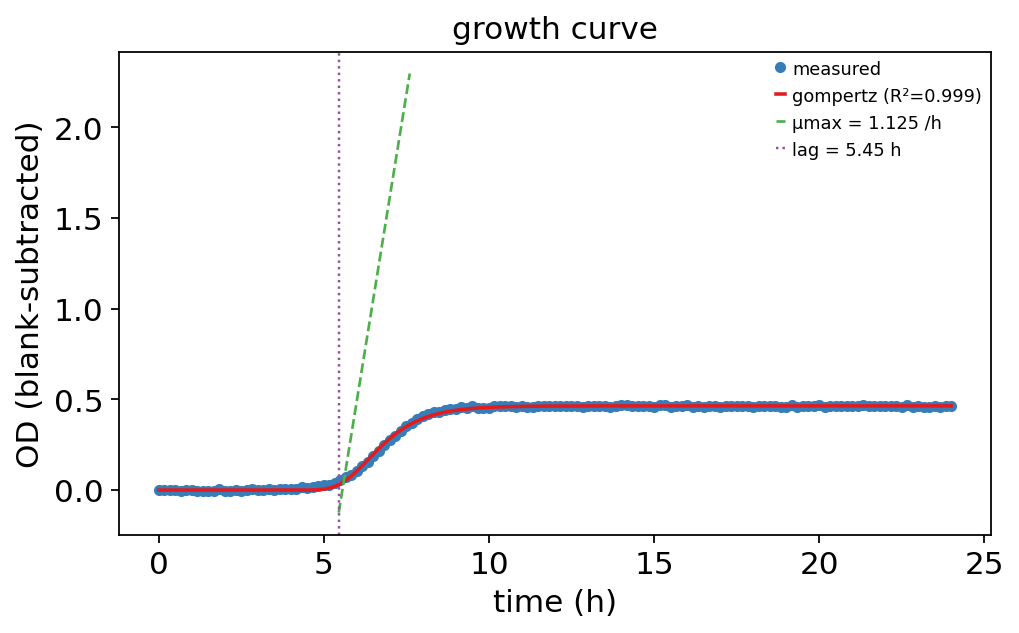

In [18]:
fit = ov.synbio.fit_growth_curve(od['time_h'], od[best_well], blank=baseline)
ov.synbio.plot_growth_curves(od['time_h'], od[best_well], fit, blank=baseline)


The green tangent is µ at the inflection and the dotted line is where it crosses the time axis — which *is* the lag. Drawing them is how you see whether the fit is reasonable rather than merely converged.

### 3.2 The coupling: measured growth against the model's prediction

This is the join only this package can make. FBA is a stoichiometric upper bound, RBA adds a proteome budget, MOMA is the nearest-feasible state after a deletion. Where a measurement falls among them is itself the result.


In [19]:
measured = fits.nlargest(3, 'mu_max')['mu_max'].to_dict()
model = ov.synbio.load_gem('textbook')
print(ov.synbio.compare_growth_to_model(measured, model).round(3).to_string())


INFO:cobra.io.web.load:Attempting to fetch 'textbook' from the Cobrapy repository.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


       measured    fba    rba  measured_over_fba  measured_over_rba
label                                                              
A7        1.125  0.874  0.874              1.287              1.287
G5        1.074  0.874  0.874              1.228              1.228
H5        1.066  0.874  0.874              1.220              1.220


Look at `measured_over_fba`: **the measured rates exceed the FBA bound by ~1.3x**, which is not possible for a correctly set up comparison. FBA is an upper bound. So the function says so:


In [20]:
table = ov.synbio.compare_growth_to_model(measured, model)
print(table.attrs['warning'])


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


3 个样品的实测 µmax 超过 FBA 上界 5% 以上 —— FBA 是化学计量上界,实测不该超过它。检查培养基约束是否比实际更严、OD 到干重的换算,或时间单位。


That is the right behaviour and the right lesson. This dataset is a plate-reader run on an unspecified organism in an unspecified medium, and `textbook` is an *E. coli* core model on 10 mmol/gDW/h glucose — the medium constraint is tighter than whatever these cells actually had, and the OD-to-dry-weight conversion is not 1. The number is a diagnostic that the comparison is not yet set up, not a discovery that the cells beat thermodynamics.

### 3.3 Dose-response

The same fitting machinery, for inhibition. `dose_response` reports EC50 under its inhibitory name only when the response actually falls with dose, and gives the MIC alongside.


In [21]:
import numpy as np

concentration = np.array([0, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0])
response = np.array([1.00, 0.99, 0.96, 0.88, 0.65, 0.35, 0.12, 0.04, 0.02])
inhibition = ov.synbio.dose_response(concentration, response)
print(inhibition)


DoseResponse(IC50=0.5402, hill=-1.13, R²=0.9995, MIC=0.07663)


(<Figure size 496x320 with 1 Axes>,
 <Axes: title={'center': 'hill slope -1.13'}, xlabel='concentration', ylabel='response'>)

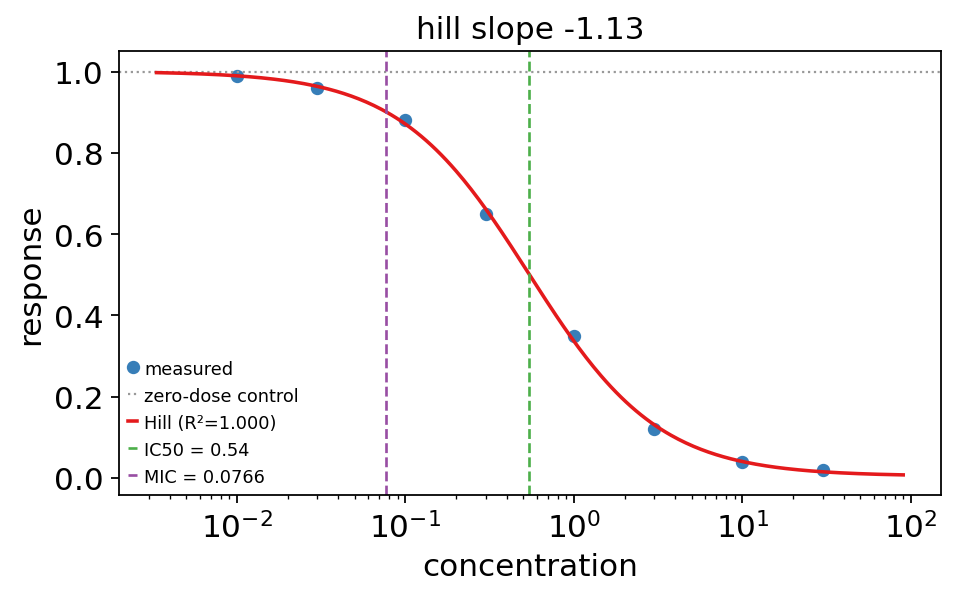

In [22]:
ov.synbio.plot_dose_response(concentration, response, inhibition)


## 4 — Learn: what the round taught, and what to do next

### 4.1 Effects

We need a response for the design. Taking the fitted growth rates as the readout gives a real measured response for the runs we laid out.


In [23]:
X = design.to_frame().values
response = fits['mu_max'].to_numpy()[:design.n_runs]
effects = ov.synbio.analyse_doe(design, response)
print(effects)
print(effects.to_frame().head(6).round(4).to_string())


DoEAnalysis(17 runs, R²=0.540, top: ['rbs^2=-0.117', 'copies=-0.0988', 'promoter=+0.0882'])
                 effect  abs_effect         kind  significant
term                                                         
rbs^2           -0.1171      0.1171    quadratic        False
copies          -0.0988      0.0988         main        False
promoter         0.0882      0.0882         main        False
promoter:rbs     0.0769      0.0769  interaction        False
rbs:copies       0.0727      0.0727  interaction        False
promoter:copies -0.0412      0.0412  interaction        False


Significance uses **Lenth's method**, not a t-test: a screening design has no replication, so there is no independent error estimate to test against. Lenth builds a pseudo-standard-error from the median of the small effects, on the reasoning that most factors in a screen do nothing — which is the situation a screen exists to establish.

Quadratic terms are included automatically here, because a central composite design has three levels. Without them the analysis fits a plane through a bowl: on a synthetic response with real curvature that reached R² 0.14 while still calling the main effects significant.


In [24]:
print('quadratic terms estimated:', list(effects.quadratics))
for note in effects.notes:
    print('-', note)


quadratic terms estimated: ['promoter^2', 'rbs^2', 'copies^2']
- Lenth PSE = 0.1091,显著阈值 |effect| > 0.2728(筛选设计通常无重复,故不用 t 检验)
- 已估计 3 个二次项 —— 响应面设计的意义所在。


(<Figure size 880x320 with 2 Axes>,
 [<Axes: title={'center': 'Pareto of effects — red = significant (Lenth), R²=0.540'}, xlabel='|effect|'>,
  <Axes: title={'center': 'main effects, signed'}, xlabel='effect (low → high)'>])

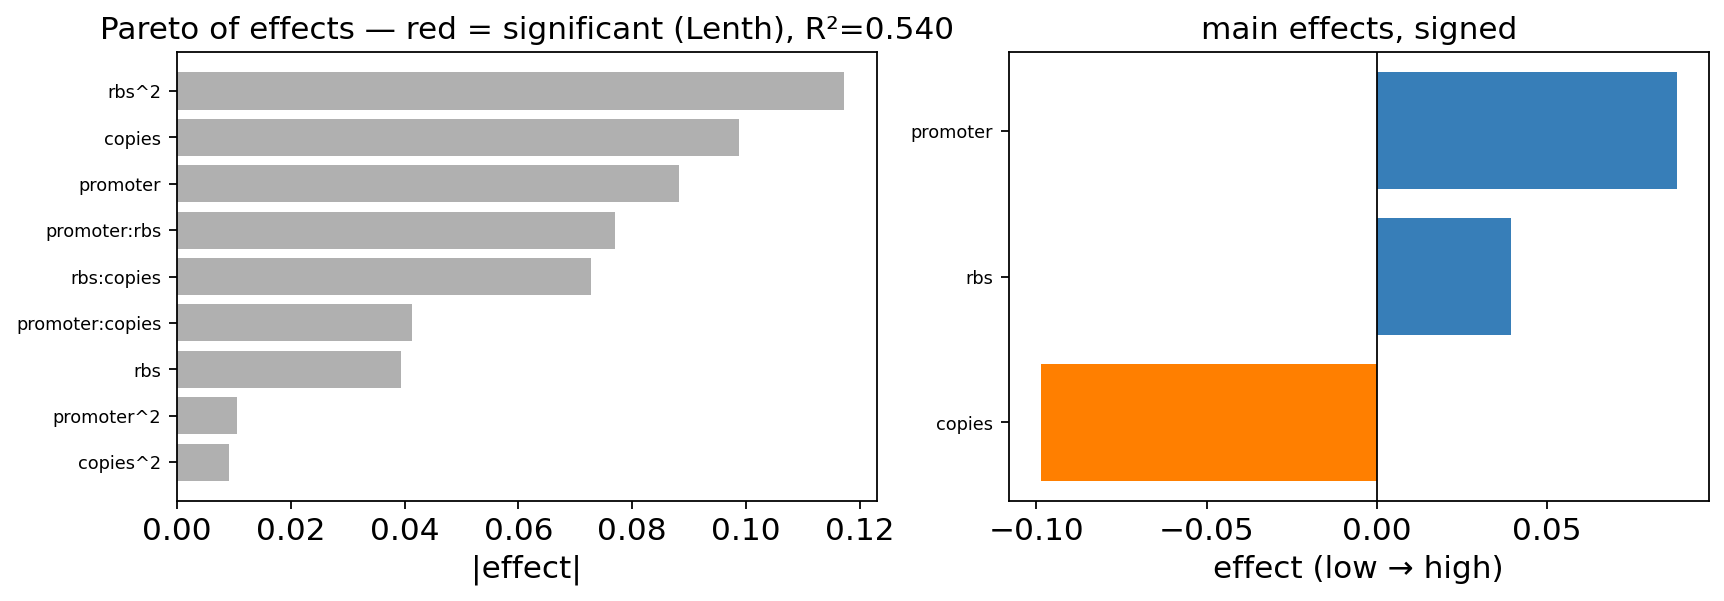

In [25]:
ov.synbio.plot_doe_effects(effects)


### 4.2 The next batch

A Gaussian process over what has been measured, and the next experiments chosen by expected improvement. This is the arrow from Learn back to Design.


In [26]:
proposal = ov.synbio.bayesian_optimize(X, response, factors, batch=4)
print(proposal)
print(proposal.to_frame().round(3).to_string())


Proposal(4 experiments, ei, best so far 0.9575)
           promoter      rbs  copies  predicted  uncertainty     ei
proposal1     0.672  502.441   1.361      0.762        0.122  0.002
proposal2     0.536  481.142  11.130      0.762        0.118  0.002
proposal3     0.744  559.296   1.469      0.762        0.115  0.002
proposal4     0.748  551.717   2.435      0.762        0.112  0.001


The four proposals are four *different* points. That is not automatic — a naive batch asks for the current optimum four times over. A constant-liar pass refits the model with each pick pinned at its posterior mean before choosing the next, which is what spreads them out.

`ei` balances exploration against exploitation; `ucb` lets you set the balance with `kappa`; `greedy` is pure exploitation and belongs only in a final confirmation round.

### 4.3 The campaign

A campaign is what makes this a cycle rather than a line: it holds every round, conditions each proposal on all of them, and answers whether the thing is still improving.


In [27]:
campaign = ov.synbio.dbtl_campaign(factors, objective='growth_rate')
campaign.record(X, response, note='round 1: central composite screen')
print(campaign)
print('best so far:', {k: round(v, 3) for k, v in campaign.best[1].items()})


DBTLCampaign(1 rounds, 17 experiments, best growth_rate=0.9575, improving=True)
best so far: {'promoter': np.float64(0.525), 'rbs': np.float64(500.5), 'copies': np.float64(10.5)}


In [28]:
campaign.record(proposal.points, response[:len(proposal.points)] * 0.9,
                note='round 2: a deliberately worse round')
print(campaign)
print('still improving:', campaign.improving)


DBTLCampaign(2 rounds, 21 experiments, best growth_rate=0.9575, improving=False)
still improving: False


(<Figure size 832x304 with 2 Axes>,
 [<Axes: title={'center': '21 experiments over 2 rounds'}, xlabel='round', ylabel='growth_rate'>,
  <Axes: title={'center': 'converged — stop'}, xlabel='round', ylabel='best growth_rate so far'>])

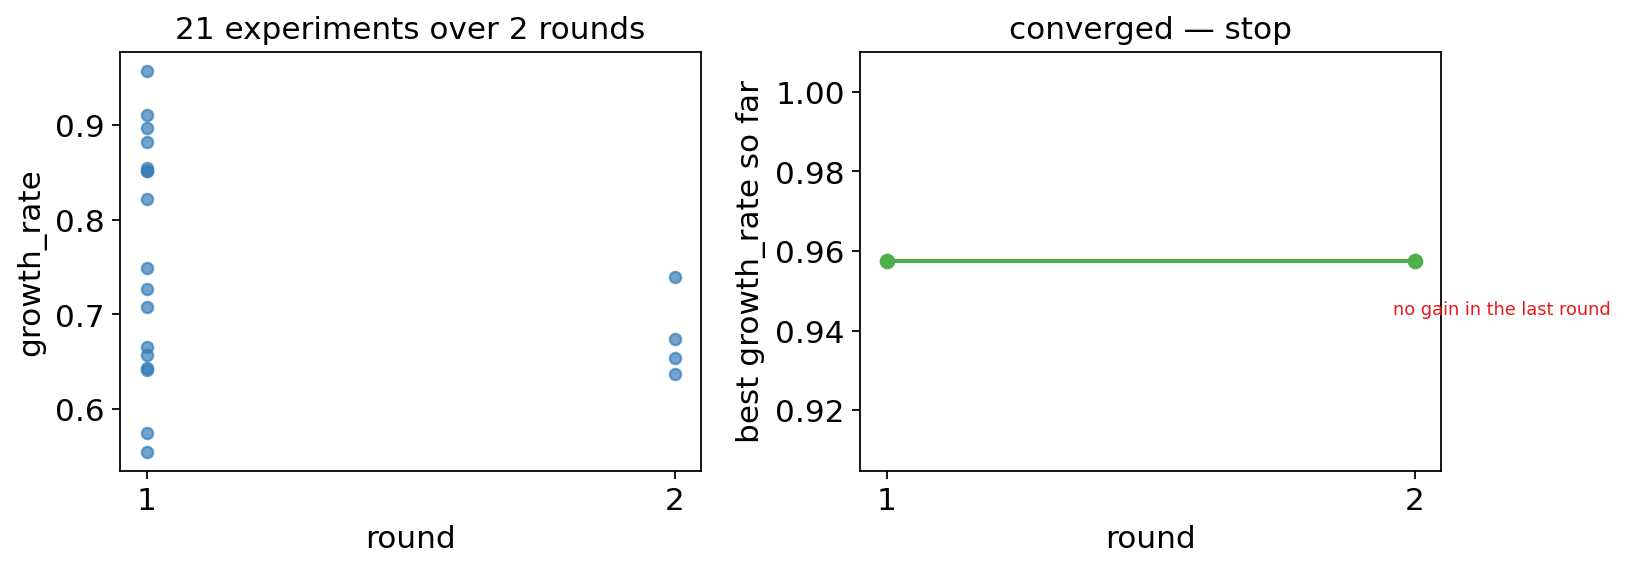

In [29]:
ov.synbio.plot_optimization_progress(campaign)


The stop signal is two consecutive rounds without improvement, not a fixed round count — a campaign that has converged is spending money to confirm what it already knows.

## 5 — Tuning: working, at the level you wanted

### 5.1 tAI, where CAI and tRNA availability disagree

`cai` measures how closely a gene's codons match the codon *usage* of highly expressed genes. `tai` measures how well they match the *tRNA pool that decodes them*, wobble interactions included. Most of the time they agree; the interesting genes are the ones where they do not.


In [30]:
native = ov.synbio.tai(ov.synbio.GAPDH_CDS, host='e_coli')
optimised = ov.synbio.tai(ov.synbio.codon_optimize(ov.synbio.GAPDH_CDS,
                                                    host='e_coli').sequence,
                          host='e_coli')
print(f'native tAI    {native.tai:.4f}')
print(f'CAI-optimised {optimised.tai:.4f}')


native tAI    0.2732
CAI-optimised 0.1985


Optimising CAI moved tAI — and not necessarily upward, because the two indices are not the same objective. `bottleneck_codons` localises the problem, which matters: a low tAI spread across the whole gene and a low tAI caused by six terrible codons need different fixes.


In [31]:
for position, codon, weight in native.bottleneck_codons(5):
    print(f'  position {position:3d}  {codon}  weight {weight:.3f}')


  position  27  AAA  weight 0.000
  position  36  CCC  weight 0.086
  position  53  CAT  weight 0.120
  position   7  GGA  weight 0.120
  position  10  GGA  weight 0.120


The built-in tRNA gene counts cover *E. coli* and yeast. For any other host, supply your own — a tAI computed with another organism's tRNA pool is not a tAI for yours, and that is the whole meaning of "species-specific".

### 5.2 A graded RBS library

`rbs_strength` scores one RBS. Tuning a pathway needs a *set* spanning orders of magnitude, and the search bins candidates on a log scale so the members spread out instead of clustering wherever the search found the most hits.


In [32]:
library = ov.synbio.rbs_library(ov.synbio.GAPDH_CDS, n=6, n_candidates=400,
                                target_range=(10, 10000))
print(library)
print(library.to_frame().round(1).to_string(index=False))


ExpressionLibrary(rbs, 6 parts, 6.72–1.29e+04 (1920x), coverage 100%)
                             sequence  predicted
TTTAAGAAGGAGATATACATAGAACGTTGCTTGCTCT        6.7
TTTAAGAAGGAGATATACATAGAGTGCCTACGCGACG       23.7
TTTAAGAAGGAGATATACATTGGCAGGATATCGCTGC      114.5
TTTAAGAAGGAGATATACATAGGAGGGGAATAACCCC      578.3
       TTTAAGAAGGAGATATACATATTAGGAGAC     2670.9
       TTTAAGAAGGAGATATACATAGGAGGGAGG    12902.4


(<Figure size 560x272 with 1 Axes>,
 <Axes: title={'center': '6 rbss, 1920x dynamic range, 100% of target covered'}, xlabel='library member (sorted)', ylabel='predicted rbs strength'>)

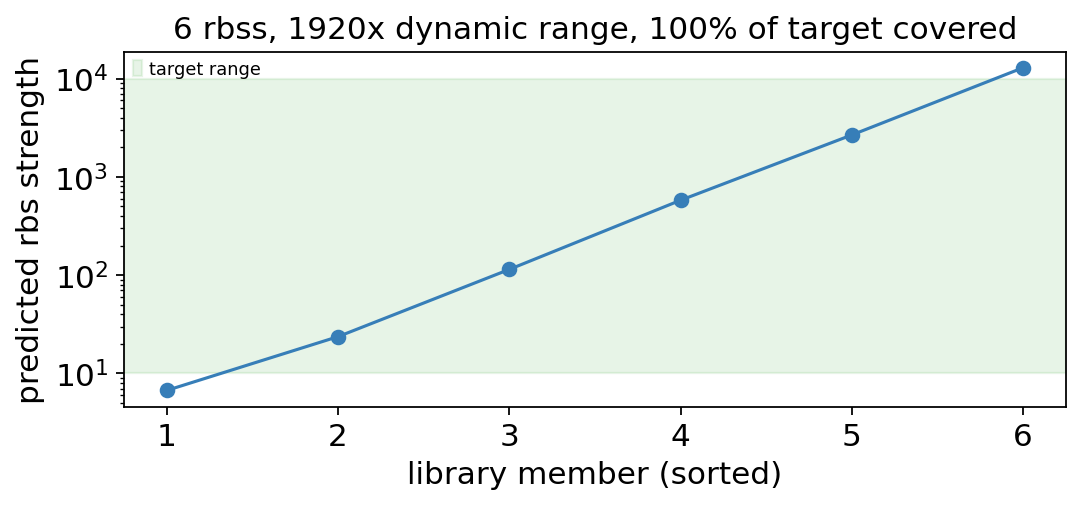

In [33]:
ov.synbio.plot_expression_library(library)


### 5.3 Where in the chromosome to put it

Expression from different genomic loci spans roughly 25% to 500% of a high-copy plasmid, so the site is a design parameter. Note what wins when you ask for high expression, and what comes with it.


In [34]:
for site in ov.synbio.integration_sites(target_expression=2.5)[:4]:
    print(f'  {site.name:20s} {site.relative_expression:.1f}x  '
          f'essential nearby: {site.essential_nearby}')


  attB(HK022)          1.2x  essential nearby: False
  attB(lambda)         1.1x  essential nearby: False
  near oriC            2.6x  essential nearby: True
  attTn7 (glmS)        1.0x  essential nearby: False


(<Figure size 592x379.2 with 1 Axes>,
 <Axes: title={'center': 'red = essential genes nearby'}, xlabel='expression relative to the neutral site'>)

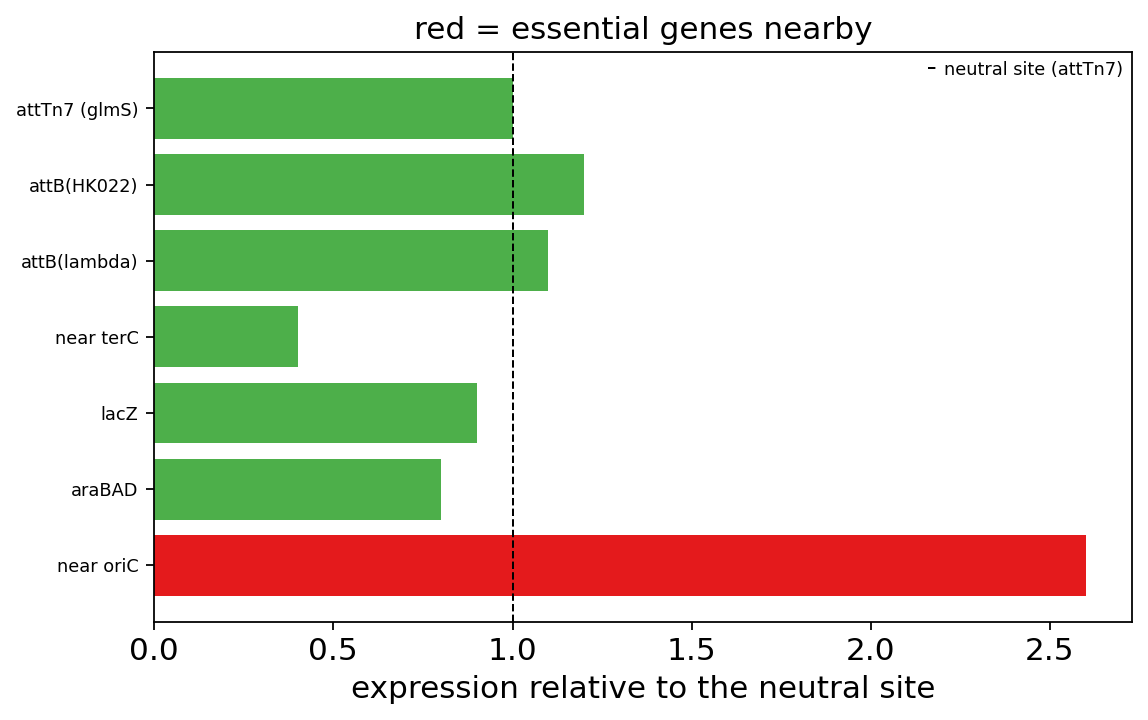

In [35]:
ov.synbio.plot_integration_sites(ov.synbio.integration_sites())


The oriC-proximal site gives the most expression — because of the replication gradient, it is present at higher copy during fast growth — and is also the one embedded in essential genes. That trade is the point of ranking rather than picking a maximum.

### 5.4 What it costs the host

Burden is reported as a **growth rate**, through the same proteome budget `rba` uses, rather than as a vague warning.


In [36]:
for copies, fraction in ((1, 0.02), (20, 0.10), (100, 0.30), (200, 0.50)):
    estimate = ov.synbio.plasmid_burden(model, copy_number=copies,
                                        expressed_protein_fraction=fraction)
    print(f'  {copies:3d} copies, {fraction:.0%} of proteome -> '
          f'{estimate.burden:5.1%} growth loss ({estimate.verdict})')


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


...

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


  200 copies, 50% of proteome -> 46.3% growth loss (will be selected against)


Past about 20% the construct is selected against: after enough generations the cells that lost it outgrow the ones that kept it. That is a design-time signal, and the result says what to change.


In [37]:
estimate = ov.synbio.plasmid_burden(model, copy_number=200,
                                    expressed_protein_fraction=0.50)
for note in estimate.notes:
    print('-', note)


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


...

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


- total_protein=0.55 对这个模型不构成约束(生长已达无约束上限 0.8739)。负担改以真正起作用的预算 0.06471 g/gDW 为基准 —— 否则任何负担都会被报成 0。
- proteome: 50.0% to the heterologous protein, 1.08% to replicating 200 x 5.0 kb, against a binding budget of 0.06471 g/gDW
- 负担 46%:培养若干代后未携带构建体的细胞会占优。考虑降低拷贝数(select_backbone 的 copy_number=)、改用染色体整合(integration_sites),或减弱启动子/RBS。


## Where this leaves the cycle

Design produced a space; a statistical design chose which corners of it to build; the Build layer emitted a plate map, a pick list, a robot protocol and a thermocycler program; the Test layer turned 96 measured OD traces into growth parameters and set them against the metabolic model; and the Learn layer ranked the effects and proposed the next four experiments, conditioned on everything measured so far.

Two honest limits worth carrying forward. The measured-versus-FBA comparison in §3.2 flagged itself as not yet set up, and that is the function working — the fix is a medium and an OD-to-dry-weight conversion that match the experiment, not a different number. And `promoter_library` will tell you that the built-in σ70 scorer spans about 1.4x: perturbing consensus boxes cannot produce a decade of transcription, and it says so instead of presenting a narrow band as a gradient.
